# Bipartite and Temporal Networks

## Overview

Bipartite networks connect two distinct node types — never nodes within the same type. Temporal networks capture how connections change over time. Both are common in ecology.

**Bipartite examples:**
- Plants × pollinators (interaction network)
- Sites × species (incidence matrix)
- Restoration actions × outcome indicators

**Temporal examples:**
- Species interaction strength changing across seasons
- Stream connectivity varying with flow regime
- Monitoring site operational status over time

**Key operations:**
- Projection: collapse bipartite graph onto one node type
- Nestedness: are generalists connected to specialists?
- Temporal aggregation: snapshot vs cumulative network

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

rng = np.random.default_rng(42)

# Build plant-pollinator bipartite network
plants     = ['Meadowsweet','Ragged_Robin','Purple_Loosestrife','Water_Mint',
               'Yellow_Flag','Marsh_Marigold']
pollinators = ['Bumblebee_A','Bumblebee_B','Hoverfly_A','Hoverfly_B',
                'Butterfly_A','Butterfly_B','Solitary_Bee']

B = nx.Graph()
B.add_nodes_from(plants,      bipartite=0)
B.add_nodes_from(pollinators, bipartite=1)

# Interaction matrix (observed visits)
interactions = [
    ('Meadowsweet','Bumblebee_A',12), ('Meadowsweet','Hoverfly_A',8),
    ('Meadowsweet','Butterfly_A',5),  ('Ragged_Robin','Bumblebee_A',9),
    ('Ragged_Robin','Bumblebee_B',6), ('Purple_Loosestrife','Bumblebee_B',14),
    ('Purple_Loosestrife','Hoverfly_B',7), ('Water_Mint','Hoverfly_A',11),
    ('Water_Mint','Solitary_Bee',8),  ('Yellow_Flag','Butterfly_A',10),
    ('Yellow_Flag','Butterfly_B',7),  ('Marsh_Marigold','Bumblebee_A',15),
    ('Marsh_Marigold','Solitary_Bee',6), ('Marsh_Marigold','Hoverfly_A',9),
]
for plant, pollinator, visits in interactions:
    B.add_edge(plant, pollinator, weight=visits)
print(f"Bipartite network: {len(plants)} plants, {len(pollinators)} pollinators")
print(f"Is bipartite: {bipartite.is_bipartite(B)}")
print(f"Edges: {B.number_of_edges()}")

Bipartite network: 6 plants, 7 pollinators
Is bipartite: True
Edges: 14


---
## Bipartite Visualisation and Projection

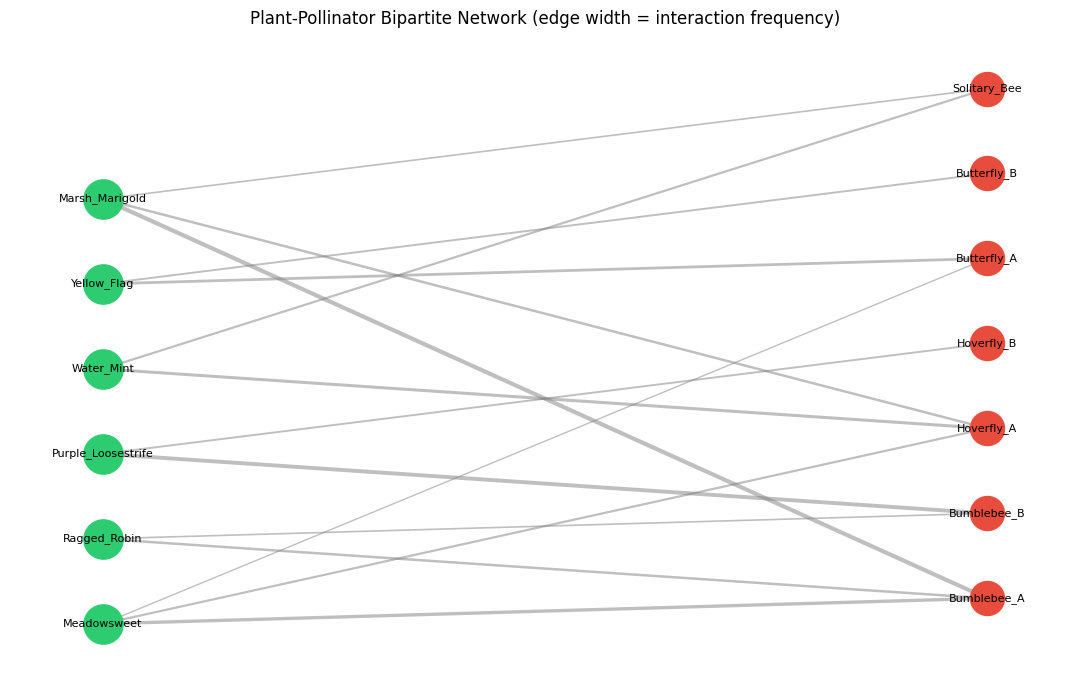


Plant projection: 6 nodes, 7 edges
Shared pollinators:
  Meadowsweet <-> Marsh_Marigold: 2 shared pollinators
  Water_Mint <-> Marsh_Marigold: 2 shared pollinators
  Meadowsweet <-> Yellow_Flag: 1 shared pollinators
  Meadowsweet <-> Water_Mint: 1 shared pollinators
  Meadowsweet <-> Ragged_Robin: 1 shared pollinators


In [5]:
# Draw bipartite layout
pos = {}
for i, p in enumerate(plants):
    pos[p] = (0, i)
for i, p in enumerate(pollinators):
    pos[p] = (3, i + 0.3)
fig, ax = plt.subplots(figsize=(11, 7))
nx.draw_networkx_nodes(B, pos, nodelist=plants,      node_color='#2ecc71',
                        node_size=800, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=pollinators, node_color='#e74c3c',
                        node_size=600, ax=ax)
widths = [B.edges[u,v]['weight']/5 for u,v in B.edges()]
nx.draw_networkx_edges(B, pos, width=widths, alpha=0.5, edge_color='grey', ax=ax)
nx.draw_networkx_labels(B, pos, font_size=8, ax=ax)
ax.set_title('Plant-Pollinator Bipartite Network (edge width = interaction frequency)')
ax.axis('off'); plt.tight_layout(); plt.show()

# Projection onto plants: two plants connected if they share a pollinator
plant_proj = bipartite.weighted_projected_graph(B, plants)
print(f"\nPlant projection: {plant_proj.number_of_nodes()} nodes, {plant_proj.number_of_edges()} edges")
print("Shared pollinators:")
for u,v,d in sorted(plant_proj.edges(data=True), key=lambda x: -x[2]['weight'])[:5]:
    print(f"  {u} <-> {v}: {d['weight']} shared pollinators")

---
## Nestedness Analysis

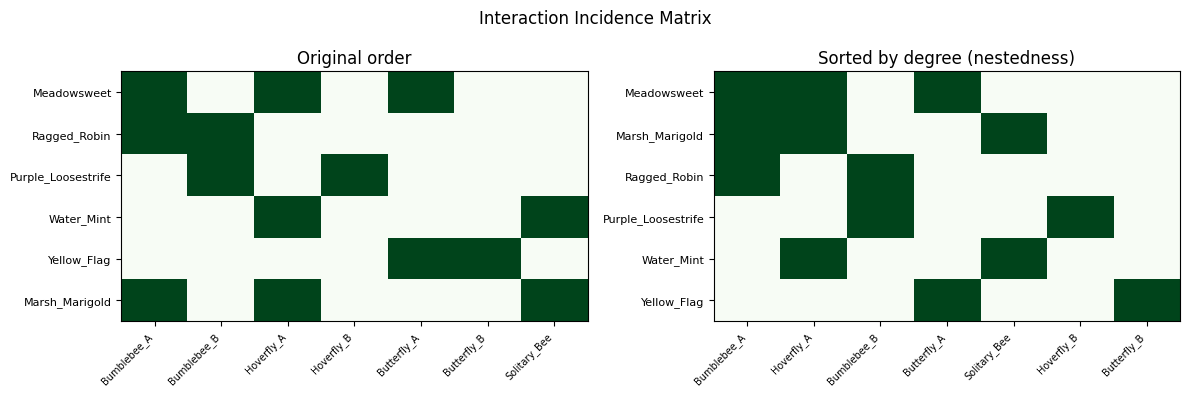

Connectance (filled fraction): 0.333


In [6]:
# Nestedness: specialists tend to interact with subsets of what generalists interact with
# Perfect nestedness: interaction matrix has staircase pattern
# Build incidence matrix
inc_matrix = pd.DataFrame(0, index=plants, columns=pollinators)
for p, pol, _ in interactions:
    inc_matrix.loc[p, pol] = 1
# Sort by degree for nestedness visualisation
plant_order = inc_matrix.sum(axis=1).sort_values(ascending=False).index
poll_order  = inc_matrix.sum(axis=0).sort_values(ascending=False).index
inc_sorted  = inc_matrix.loc[plant_order, poll_order]
fig, axes   = plt.subplots(1, 2, figsize=(12, 4))
for ax, mat, title in [(axes[0], inc_matrix, 'Original order'),
                        (axes[1], inc_sorted, 'Sorted by degree (nestedness)')]:
    ax.imshow(mat.values, cmap='Greens', aspect='auto', interpolation='none')
    ax.set_xticks(range(len(pollinators)))
    ax.set_xticklabels(list(mat.columns), rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(plants)))
    ax.set_yticklabels(list(mat.index), fontsize=8)
    ax.set_title(title)
plt.suptitle('Interaction Incidence Matrix')
plt.tight_layout(); plt.show()
# Connectance
connectance = inc_matrix.values.sum() / (len(plants) * len(pollinators))
print(f"Connectance (filled fraction): {connectance:.3f}")

---
## Temporal Network: Seasonal Connectivity

In [7]:
# Temporal network: stream connectivity changes across seasons
# Same sites, but edge presence/strength varies seasonally
sites = [f'S{i:02d}' for i in range(1, 9)]
seasons = ['Spring','Summer','Autumn','Winter']

# Generate temporal edge sets (different connectivity each season)
temporal_edges = {}
base_edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(0,3),(1,4),(2,5)]
for season in seasons:
    G_t = nx.Graph(); G_t.add_nodes_from(sites)
    for u_i, v_i in base_edges:
        # Some edges drop in summer (drought) or winter (ice)
        if season == 'Summer' and u_i in [3,4]: continue
        if season == 'Winter' and u_i in [5,6]: continue
        flow = rng.uniform(0.5, 5.0)
        G_t.add_edge(sites[u_i], sites[v_i], flow=flow)
    temporal_edges[season] = G_t

print("Temporal network connectivity by season:")
for season, G_t in temporal_edges.items():
    lcc = len(max(nx.connected_components(G_t), key=len))
    print(f"  {season:8s}: edges={G_t.number_of_edges()}, LCC={lcc}/{len(sites)}, "
          f"density={nx.density(G_t):.3f}")

Temporal network connectivity by season:
  Spring  : edges=10, LCC=8/8, density=0.357
  Summer  : edges=8, LCC=8/8, density=0.286
  Autumn  : edges=10, LCC=8/8, density=0.357
  Winter  : edges=8, LCC=6/8, density=0.286


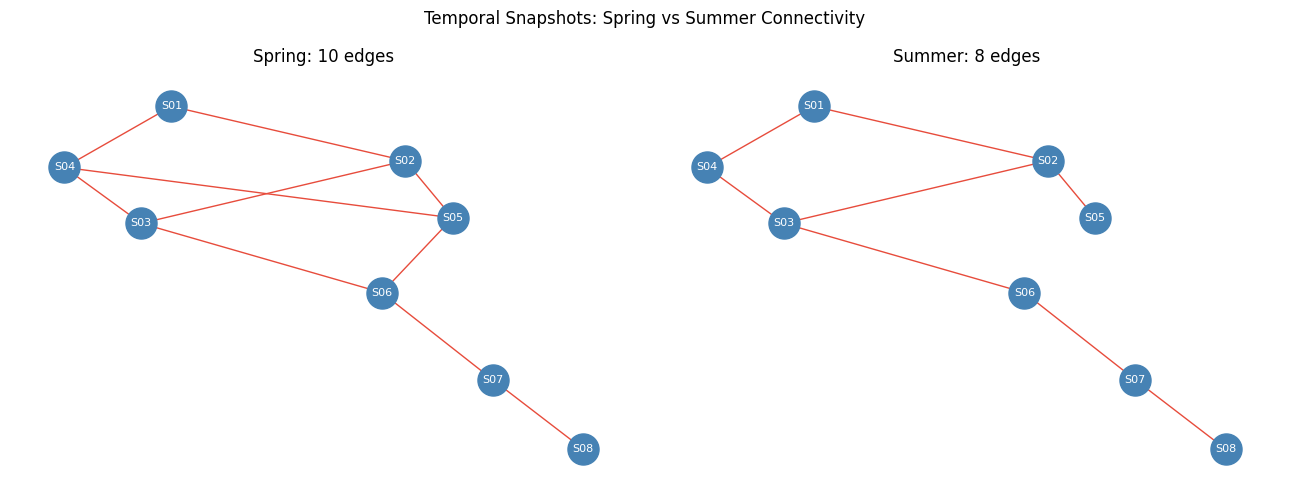


Edge persistence (seasons present out of 4):
  1 seasons: 0 edges
  2 seasons: 0 edges
  3 seasons: 4 edges
  4 seasons: 6 edges


In [8]:
# Aggregate temporal network: edges present in at least 2 seasons
G_agg = nx.Graph(); G_agg.add_nodes_from(sites)
edge_presence = {}
for season, G_t in temporal_edges.items():
    for u,v in G_t.edges():
        key = tuple(sorted([u,v]))
        edge_presence[key] = edge_presence.get(key, 0) + 1
for (u,v), count in edge_presence.items():
    G_agg.add_edge(u, v, persistence=count)
pos_t = nx.spring_layout(G_agg, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (season, G_t) in zip(axes, list(temporal_edges.items())[:2]):
    nx.draw_networkx(G_t, pos=pos_t, ax=ax, node_color='steelblue',
        node_size=500, font_size=8, font_color='white', edge_color='#e74c3c')
    ax.set_title(f'{season}: {G_t.number_of_edges()} edges')
    ax.axis('off')
plt.suptitle('Temporal Snapshots: Spring vs Summer Connectivity')
plt.tight_layout(); plt.show()
# Persistence distribution
persist_vals = [d['persistence'] for u,v,d in G_agg.edges(data=True)]
print(f"\nEdge persistence (seasons present out of 4):")
for k in range(1, 5):
    print(f"  {k} seasons: {persist_vals.count(k)} edges")

---

## Common Pitfalls

**1. Using `nx.Graph` methods that assume unipartite structure on bipartite graphs**  
Standard clustering coefficient and many other NetworkX metrics assume any two nodes can potentially be connected. In bipartite graphs, nodes within the same partition cannot connect by definition. Use `bipartite.clustering()` and other bipartite-specific functions from `nx.algorithms.bipartite`.

**2. Projecting a bipartite network without normalising by degree**  
A simple weighted projection counts shared neighbours. Generalist species (high degree) inflate shared-neighbour counts for all their partners. Use normalised projections (`bipartite.collaboration_weighted_projected_graph()`) to account for degree when comparing connection strengths.

**3. Treating a temporal network as a single aggregate without checking temporal variation**  
Aggregating across time periods hides important temporal dynamics — a connection present in only one season is treated the same as a year-round connection. Always report edge persistence alongside aggregate structure, and analyse seasonal or temporal snapshots separately for ecologically meaningful insights.

**4. Conflating connectance with network completeness**  
Low connectance in an interaction network may reflect true ecological specialisation *or* sampling incompleteness — rare interactions are easily missed. Always assess sampling effort and report the number of interaction observations per species alongside connectance.

**5. Sorting the incidence matrix by degree and concluding the network is nested**  
Visually sorting rows and columns by degree always makes *any* matrix look more nested. The sorted appearance is not evidence of nestedness. Always compute a formal nestedness metric (e.g. NODF — Nestedness metric based on Overlap and Decreasing Fill) and compare it to a null model (fixed-row/column-sum randomisation).

---
*python_methods_library - Samantha McGarrigle*